In [360]:
import numpy as np
from StatTools.generators.ndfnoise_generator import ndfnoise
# from StatTools.generators.multi_scale_fractional_generator import MultiScaleFractionalGenerator
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from IPython.display import clear_output
from cv2 import KalmanFilter
def gen_traj(frame_num: int, ants_num: int, frame_shape: tuple, margin:int = 10,
             hurst_move: float = 0.5, hurst_species: float = 0.5, 
             start_point = None):

    dx = ndfnoise(shape=(frame_num, ants_num), hurst=[hurst_move, hurst_species], normalize=True, dtype=np.float32)
    dy = ndfnoise(shape=(frame_num, ants_num), hurst=[hurst_move, hurst_species], normalize=True, dtype=np.float32)

    x = dx.cumsum(axis=0).round().astype(np.int32)
    y = dy.cumsum(axis=0).round().astype(np.int32)

    if start_point is None:
        start_x = np.random.randint(-margin, frame_shape[1] + margin, (ants_num,))
        start_y = np.random.randint(-margin, frame_shape[0] + margin, (ants_num,))
        start_point = np.stack([start_x, start_y], axis=1)

    trajectories = np.stack([x, y], axis=2)
    trajectories = trajectories + start_point

    return trajectories

# one track

In [361]:
np.random.seed(42)
traj = gen_traj(frame_num=1000, 
                ants_num=1, 
                frame_shape=(500, 500), 
                margin = -10,
                hurst_move = 1.2,
                hurst_species = 0.5, 
                start_point = None)

In [362]:
kf = KalmanFilter(dynamParams = 4, measureParams = 2)

kf.measurementMatrix = np.array([[1,0,0,0],
                                 [0,1,0,0]], np.float32)

kf.transitionMatrix = np.array([[1,0,1,0],
                                [0,1,0,1], 
                                [0,0,1,0], 
                                [0,0,0,1]], np.float32)

kf.processNoiseCov = np.eye(4, dtype=np.float32) * 1e-2 
kf.measurementNoiseCov = np.eye(2, dtype=np.float32) * 1e-1
kf.statePost = np.array([[traj[0, 0, 0]], [traj[0, 0, 1]], [0], [0]], np.float32)
kalman_preds = []
for detections in traj[1:]:
    for ant_det in detections:
        x_pred, y_pred, _, _ = kf.predict()
        kf.correct(np.array([[np.float32(ant_det[0])], [np.float32(ant_det[1])]], np.float32))
        kalman_preds.append([*x_pred, *y_pred])

kalman_preds = np.stack(kalman_preds, axis=0)
kalman_preds = np.expand_dims(kalman_preds, axis=1)

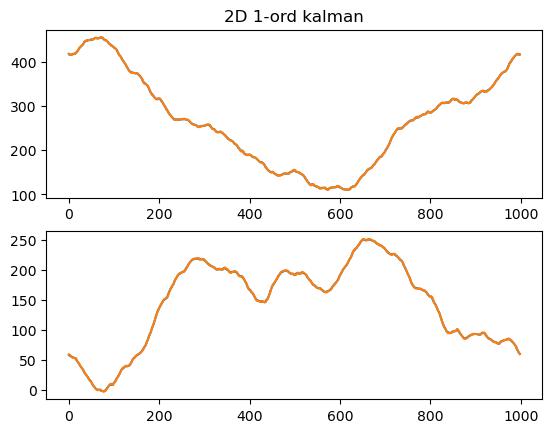

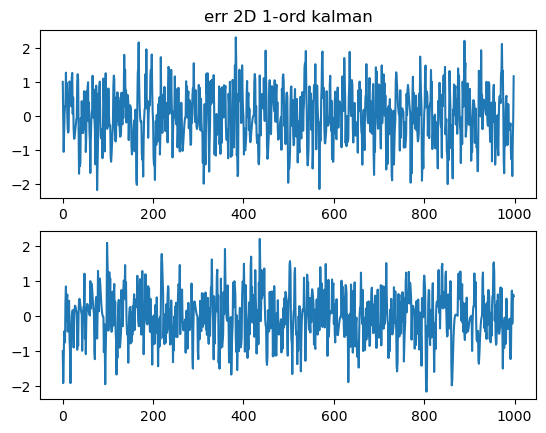

rmse=0.7999


In [363]:
fig, ax = plt.subplots(nrows=2)

ax[0].plot(traj[1:,0,0])
ax[0].plot(kalman_preds[:,0,0])
ax[1].plot(traj[1:,0,1])
ax[1].plot(kalman_preds[:,0,1])
ax[0].set_title('2D 1-ord kalman')
plt.show()

fig, ax = plt.subplots(nrows=2)
ax[0].plot(traj[1:,0,0]-kalman_preds[:,0,0])
ax[1].plot(traj[1:,0,1]-kalman_preds[:,0,1])
ax[0].set_title('err 2D 1-ord kalman')
plt.show()

rmse = np.sqrt(np.mean((traj[1:,0,0]-kalman_preds[:,0,0])**2))
print(f'{rmse=:.4f}')

# few tracks

In [364]:
class KalmanPredictor():
    def __init__(self):
        self.kf_states = {}

    def _init_kf(self, pos):
        kf = KalmanFilter(dynamParams = 4, measureParams = 2)
        kf.measurementMatrix = np.array([[1,0,0,0],
                                        [0,1,0,0]], np.float32)

        kf.transitionMatrix = np.array([[1,0,1,0],
                                        [0,1,0,1], 
                                        [0,0,1,0], 
                                        [0,0,0,1]], np.float32)

        kf.processNoiseCov = np.eye(4, dtype=np.float32) * 1e-2 
        kf.measurementNoiseCov = np.eye(2, dtype=np.float32) * 1e-1
        kf.statePost = np.array([[pos[0]], [pos[1]], [0], [0]], np.float32)

        return kf
    
    def predict_update(self, tracks):
        predictions = []
        for tid in range(tracks.shape[1]):
            kf = self.kf_states[tid]
            x_pred, y_pred, _, _ = kf.predict()
            kf.correct(np.array([[np.float32(tracks[0][tid][0])], [np.float32(tracks[0][tid][1])]], np.float32))
            predictions[tid] = [*x_pred, *y_pred]
            
        return predictions


In [365]:
np.random.seed(42)
traj = gen_traj(frame_num=1000, 
                ants_num=100, 
                frame_shape=(500, 500), 
                margin = -10,
                hurst_move = 1.2,
                hurst_species = 0.5, 
                start_point = None)


In [366]:
kp = KalmanPredictor()
kf_dict = {}
for tid in range(traj.shape[1]):
    kf_dict[tid] = kp._init_kf(traj[0, tid])

from collections import defaultdict
predictions = defaultdict(list)
for tid in range(traj.shape[1]):
    
    kf = kf_dict[tid]
    for detections in traj[1:, tid, :]:
        x_pred, y_pred, _, _ = kf.predict()
        kf.correct(np.array([[np.float32(detections[0])], [np.float32(detections[1])]], np.float32))
        predictions[tid].append([*x_pred, *y_pred])


In [367]:
kalman_preds = np.stack(list(predictions.values())).transpose((1,0,2))

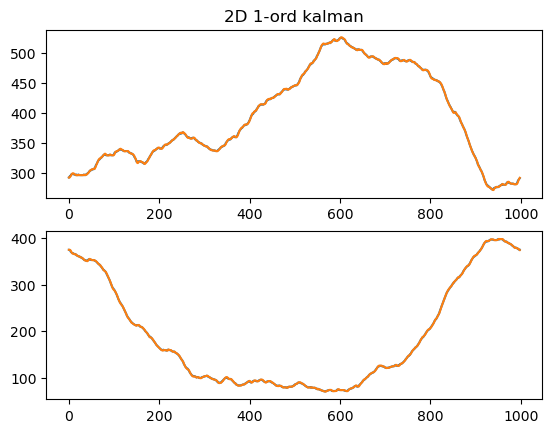

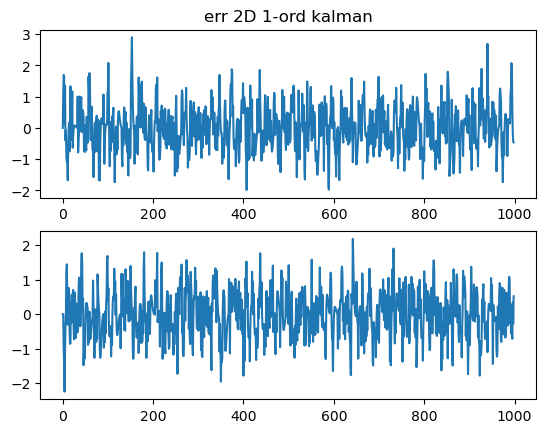

rmse=0.7001


In [368]:
fig, ax = plt.subplots(nrows=2)

ax[0].plot(traj[1:,0,0])
ax[0].plot(kalman_preds[:,0,0])
ax[1].plot(traj[1:,0,1])
ax[1].plot(kalman_preds[:,0,1])
ax[0].set_title('2D 1-ord kalman')
plt.show()

fig, ax = plt.subplots(nrows=2)
ax[0].plot(traj[1:,0,0]-kalman_preds[:,0,0])
ax[1].plot(traj[1:,0,1]-kalman_preds[:,0,1])
ax[0].set_title('err 2D 1-ord kalman')
plt.show()

rmse = np.sqrt(np.mean((traj[1:]-kalman_preds)**2))
print(f'{rmse=:.4f}')